### Plotting Nearest-Neighbor Distance (NND) Metrics

- Load nearest-neighbour distance (NND) data
- Apply a consistent lek ordering and labels
- Plot NND metrics against the lek ID

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
## Output folder
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load NND metrics
nnd_all = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['Velavadar_LEK1', 'Velavadar_LEK2', 'TalChhapar_TC']
lek_labels = {'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2','TalChhapar_TC': 'Tal Chhapar'}

nnd_all['lek_id'] = (pd.Categorical(nnd_all['lek_id'], categories=lek_order, ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Velavadar Lek 1': '#2F7F7B', 'Velavadar Lek 2': '#6FB7B3', 'Tal Chhapar': '#B5542D'}
point_cols = {'Velavadar Lek 1': '#1F5F5B', 'Velavadar Lek 2': '#8FD0CC', 'Tal Chhapar': '#D97A52'}

lek_labels = nnd_all['lek_id'].cat.categories.tolist()

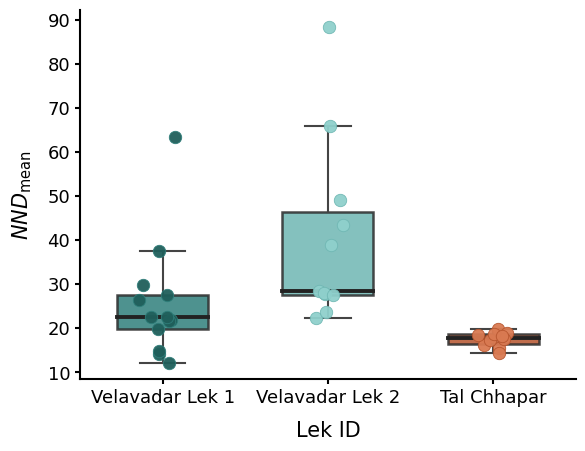

In [5]:
fig, ax = plt.subplots()

data_by_lek = [nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_mean'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_mean'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{mean}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_mean.png', dpi=300, bbox_inches='tight')

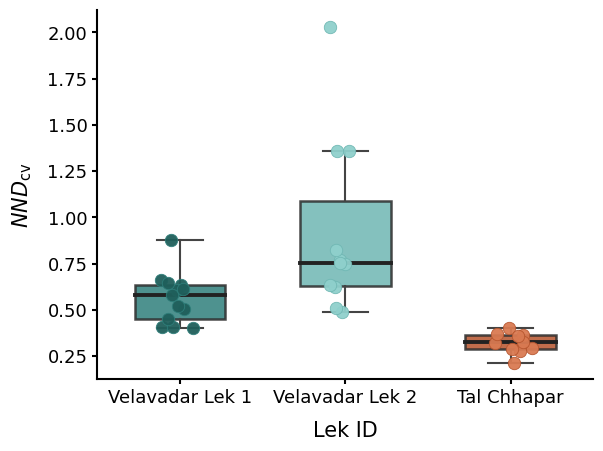

In [6]:
fig, ax = plt.subplots()

data_by_lek = [nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_cv'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_cv'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{cv}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_cv.png', dpi=300, bbox_inches='tight')

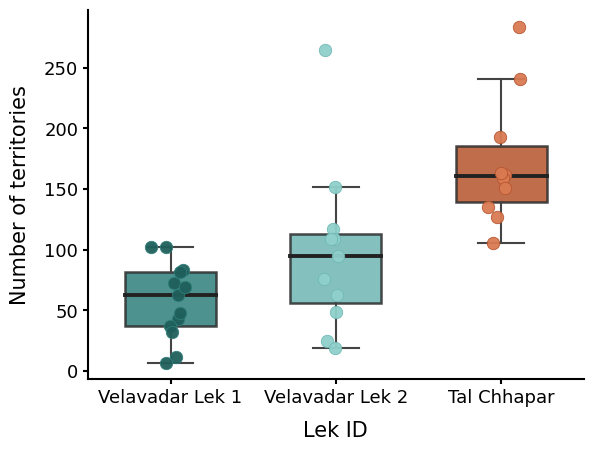

In [7]:
fig, ax = plt.subplots()

data_by_lek = [nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_count'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_count'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel('Number of territories', fontsize=15, labelpad=10)


plt.savefig(out_dir/'territory_count.png', dpi=300, bbox_inches='tight')